# TT-18 — 02. Gradient Boosting Regressor & Đánh giá nghiệp vụ
### Ames Housing — Thẩm định giá nhà tự động (AVM)

Notebook này thực hiện các bước 6–13 của đề bài:
6. Baseline (Dummy, Linear, Ridge)
7. Gradient Boosting + early stopping
8. Biểu đồ train/validation loss theo số cây
9. Feature engineering (TotalSF, TuoiNha, DaSuaChua) + so sánh trước/sau
10. Hồi quy phân vị 10/50/90 → khoảng giá
11. Median APE (chuẩn ngành AVM)
12. Cơ chế human-in-the-loop
13. So sánh tốc độ GradientBoosting vs HistGradientBoosting

Dữ liệu đầu vào lấy từ `data/processed/` do notebook `01_data_cleaning.ipynb` tạo ra.

## 0. Import & load dữ liệu đã xử lý từ notebook 01

In [2]:
import sys, os, time
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from features import load_and_clean, add_engineered_features, build_feature_pipeline

RANDOM_STATE = 42

def rmse(y_true, y_pred):
    # Không dùng squared=False vì tham số này đã bị loại khỏi sklearn >= 1.6
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

X = joblib.load('../dataset/processed/X_features.joblib')
y_log = joblib.load('../dataset/processed/y_log.joblib')
encoder = joblib.load('../dataset/processed/encoder.joblib')

print('X:', X.shape, '| y_log:', y_log.shape)

X: (1460, 235) | y_log: (1460,)


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, '| Validation:', X_val.shape)

Train: (1168, 235) | Validation: (292, 235)


## 6. Baseline models

So sánh với GBR sau này để biết boosting thực sự "ăn tiền" bao nhiêu.

In [4]:
baselines = {
    'Dummy (mean)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
}

baseline_results = {}
for name, model in baselines.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    score = rmse(y_val, pred)
    baseline_results[name] = score
    print(f'{name:20s} RMSE(log) = {score:.4f}')

Dummy (mean)         RMSE(log) = 0.4332
Linear Regression    RMSE(log) = 0.1417
Ridge (alpha=10)     RMSE(log) = 0.1363


## 7. Gradient Boosting Regressor + Early Stopping

`n_iter_no_change=50` sẽ tự dừng khi validation loss không cải thiện
sau 50 cây liên tiếp — giúp tránh overfit mà không cần tự tay dò `n_estimators`.

In [5]:
gbr = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    max_features='sqrt',
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=RANDOM_STATE,
)
gbr.fit(X_train, y_train)

pred_val_log = gbr.predict(X_val)
print(f'Số cây thực tế dùng (early stopping): {gbr.n_estimators_}')
print(f'RMSE(log) trên validation: {rmse(y_val, pred_val_log):.4f}')

Số cây thực tế dùng (early stopping): 308
RMSE(log) trên validation: 0.1366


## 8.  Biểu đồ train/validation loss theo số cây

Điểm mà 2 đường bắt đầu tách xa nhau là dấu hiệu overfit.

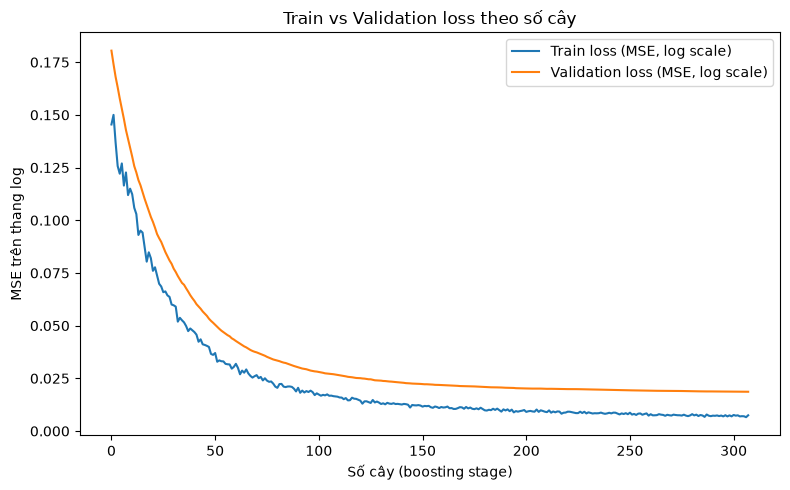

In [6]:
val_score = np.zeros(gbr.n_estimators_, dtype=np.float64)
for i, y_pred_stage in enumerate(gbr.staged_predict(X_val)):
    val_score[i] = mean_squared_error(y_val, y_pred_stage)

plt.figure(figsize=(8, 5))
plt.plot(gbr.train_score_, label='Train loss (MSE, log scale)')
plt.plot(val_score, label='Validation loss (MSE, log scale)')
plt.xlabel('Số cây (boosting stage)')
plt.ylabel('MSE trên thang log')
plt.title('Train vs Validation loss theo số cây')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/loss_theo_so_cay.png', dpi=120)
plt.show()

## 9. Feature Engineering: so sánh trước / sau

So sánh RMSE khi có và không có `TotalSF`, `TuoiNha`, `DaSuaChua`, `TotalBath`.

In [7]:
# X đã bao gồm feature engineering (được add_engineered_features xử lý
# trong build_feature_pipeline ở notebook 01). Để so sánh, ta loại các cột
# mới ra và train lại.
engineered_cols = [c for c in ['TotalSF', 'TuoiNha', 'DaSuaChua', 'TotalBath'] if c in X.columns]
print('Các cột được thêm bởi feature engineering:', engineered_cols)

X_before = X.drop(columns=engineered_cols)
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_before, y_log, test_size=0.2, random_state=RANDOM_STATE
)

gbr_before = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
).fit(Xb_train, yb_train)
rmse_before = rmse(yb_val, gbr_before.predict(Xb_val))

gbr_after = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
).fit(X_train, y_train)
rmse_after = rmse(y_val, gbr_after.predict(X_val))

print(f'RMSE(log) TRƯỚC feature engineering: {rmse_before:.4f}')
print(f'RMSE(log) SAU feature engineering:   {rmse_after:.4f}')
print(f'Cải thiện: {(rmse_before - rmse_after) / rmse_before * 100:.2f}%')

Các cột được thêm bởi feature engineering: ['TotalSF', 'TuoiNha', 'DaSuaChua', 'TotalBath']
RMSE(log) TRƯỚC feature engineering: 0.1397
RMSE(log) SAU feature engineering:   0.1390
Cải thiện: 0.50%


## 10–11. Hồi quy phân vị (10/50/90) + Median APE

`loss='quantile'` cho phép huấn luyện một cây riêng để dự đoán từng
phân vị của phân phối giá, thay vì chỉ một con số trung bình.

**Lưu ý quan trọng:** phải `expm1()` trước khi tính APE — tính trên
thang log sẽ ra con số vô nghĩa so với nghiệp vụ.

In [8]:
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    m = GradientBoostingRegressor(
        loss='quantile', alpha=q,
        n_estimators=500, learning_rate=0.05, max_depth=3,
        random_state=RANDOM_STATE,
    )
    m.fit(X_train, y_train)
    quantile_models[q] = m

pred_low  = np.expm1(quantile_models[0.1].predict(X_val))
pred_mid  = np.expm1(quantile_models[0.5].predict(X_val))
pred_high = np.expm1(quantile_models[0.9].predict(X_val))
y_true    = np.expm1(y_val)

ape = np.abs(pred_mid - y_true) / y_true * 100
median_ape = np.median(ape)
coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()

print(f'Median APE: {median_ape:.2f}%  (mục tiêu < 12%)')
print(f'Tỉ lệ phủ thực tế của khoảng 10-90%: {coverage*100:.1f}%  (kỳ vọng ~80%)')

Median APE: 5.38%  (mục tiêu < 12%)
Tỉ lệ phủ thực tế của khoảng 10-90%: 69.9%  (kỳ vọng ~80%)


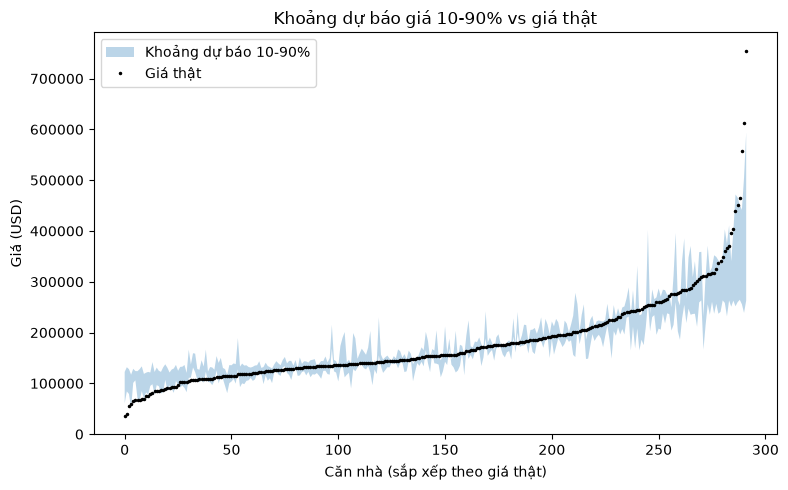

In [9]:
idx = np.argsort(np.array(y_true))
y_true_arr = np.array(y_true)[idx]
pred_low_arr = np.array(pred_low)[idx]
pred_high_arr = np.array(pred_high)[idx]

plt.figure(figsize=(8, 5))
plt.fill_between(range(len(idx)), pred_low_arr, pred_high_arr,
                  alpha=0.3, label='Khoảng dự báo 10-90%')
plt.plot(range(len(idx)), y_true_arr, 'k.', markersize=3, label='Giá thật')
plt.xlabel('Căn nhà (sắp xếp theo giá thật)')
plt.ylabel('Giá (USD)')
plt.title('Khoảng dự báo giá 10-90% vs giá thật')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/khoang_gia.png', dpi=120)
plt.show()

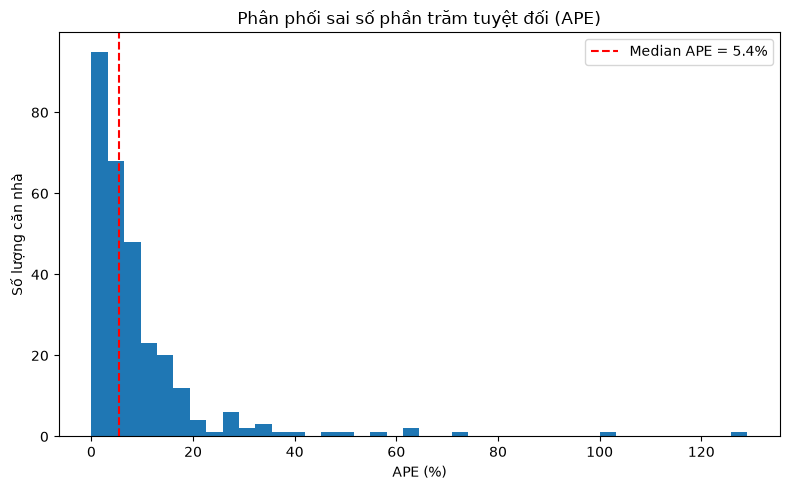

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(ape, bins=40)
plt.axvline(median_ape, color='red', linestyle='--', label=f'Median APE = {median_ape:.1f}%')
plt.xlabel('APE (%)')
plt.ylabel('Số lượng căn nhà')
plt.title('Phân phối sai số phần trăm tuyệt đối (APE)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/ape_distribution.png', dpi=120)
plt.show()

## 12. Cơ chế Human-in-the-loop

Nếu khoảng dự báo (10–90%) quá rộng so với giá trung vị (>25%),
hồ sơ được tự động chuyển cho thẩm định viên thay vì duyệt tự động.

In [11]:
width_pct = (pred_high - pred_low) / pred_mid * 100
auto_approved = width_pct <= 25

summary_df = pd.DataFrame({
    'Nhóm': ['Tự động duyệt', 'Chuyển thẩm định viên'],
    'Số lượng': [auto_approved.sum(), (~auto_approved).sum()],
    'Tỉ lệ (%)': [auto_approved.mean()*100, (~auto_approved).mean()*100],
})
summary_df

,Nhóm,Số lượng,Tỉ lệ (%)
0,Tự động duyệt,166,56.849315
1,Chuyển thẩm định viên,126,43.150685


## 13. So sánh thời gian train: GradientBoosting vs HistGradientBoosting

In [12]:
speed_models = {
    'GradientBoostingRegressor': GradientBoostingRegressor(
        n_estimators=500, max_depth=3, random_state=RANDOM_STATE
    ),
    'HistGradientBoostingRegressor': HistGradientBoostingRegressor(
        max_iter=500, max_depth=3, random_state=RANDOM_STATE
    ),
}

speed_results = {}
for name, model in speed_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    speed_results[name] = elapsed
    print(f'{name:32s}: {elapsed:.2f}s')

GradientBoostingRegressor       : 3.02s
HistGradientBoostingRegressor   : 1.04s


## Lưu model cuối cùng

In [13]:
os.makedirs('../models', exist_ok=True)

joblib.dump({
    'encoder': encoder,
    'model_mean': gbr,
    'quantile_models': quantile_models,
    'feature_columns': X.columns.tolist(),
}, '../models/gbr_pipeline.joblib')

print('Đã lưu pipeline đầy đủ tại models/gbr_pipeline.joblib')

Đã lưu pipeline đầy đủ tại models/gbr_pipeline.joblib
